# Segmentation client RFM par K-Means
**Framework Machine Learning — Apprentissage non supervisé**
Réalisé par : Soh Honoré Laurent — IABD B3 — 2025/2026

Ce notebook segmente les clients d'un site e-commerce à partir de leur comportement d'achat (modèle RFM), puis applique l'algorithme K-Means. DBSCAN est exploré en fin de notebook comme amélioration.

## Partie 1  Compréhension

On importe les bibliothèques nécessaires, puis on charge le jeu de données et on explore sa structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [2]:
# Charger le dataset
df = pd.read_excel("data/Sales_Data.xlsx")

# Aperçu
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Informations sur les colonnes et types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


**Question : combien d'observations contient le dataset ?**

Le jeu de données contient **541 909 transactions** (lignes) réparties sur 8 colonnes. Chaque ligne correspond à un produit acheté au sein d'une facture. On remarque que deux colonnes ont des valeurs manquantes : `Description` et surtout `CustomerID`.

## Partie 2 - Prétraitement avancé

On nettoie les données : suppression des valeurs nulles, des doublons et des transactions invalides. La colonne `InvoiceDate` est déjà reconnue comme une date, aucune conversion n'est nécessaire.

In [4]:
# Compter les valeurs manquantes par colonne
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Supprimer les lignes sans CustomerID (essentiel pour le RFM)
df = df.dropna(subset=['CustomerID'])

In [6]:
# Supprimer les lignes en double
df = df.drop_duplicates()

In [7]:
# Nouvelles dimensions après nettoyage
df.shape

(401604, 8)

In [8]:
# Garder uniquement les achats valides
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

**Question : pourquoi supprimer les lignes sans CustomerID ?**

Le modèle RFM se calcule **par client**. Une transaction sans identifiant client ne peut être rattachée à personne : elle est donc inutilisable pour la segmentation. C'est pourquoi on supprime ces ~135 000 lignes. On retire également les doublons (qui fausseraient la fréquence et le montant) et les quantités négatives (retours/annulations qui fausseraient le montant dépensé).

Après nettoyage, il reste **401 604 transactions valides**.

## Partie 3 - Feature Engineering (construction des variables RFM)

On construit les trois variables RFM pour chaque client :
- **Recency** : nombre de jours depuis le dernier achat
- **Frequency** : nombre de commandes distinctes
- **Monetary** : montant total dépensé

In [9]:
# Date de référence = lendemain du dernier achat
date_reference = df['InvoiceDate'].max() + pd.Timedelta(days=1)
date_reference

Timestamp('2011-12-10 12:50:00')

In [10]:
# Montant total par ligne d'achat
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
# Calcul du RFM par client
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (date_reference - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Renommer les colonnes
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [12]:
# Statistiques des variables RFM
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


**Lecture des statistiques RFM**

Le **Monetary** s'étale de quelques euros à près de **280 000 €**, une amplitude bien plus grande que la Recency (max 374) ou la Frequency (max 209). De plus, la moyenne du Monetary est nettement supérieure à sa médiane : quelques très gros clients tirent la moyenne vers le haut. Cette forte disparité d'échelle **justifie la normalisation** réalisée à la partie suivante.

## Partie 4 - Clustering

On normalise les variables, on détermine le nombre optimal de clusters (méthode du coude + score de silhouette), on applique K-Means et on visualise les segments.

In [13]:
# Normalisation des variables RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled[:5]


array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

**Question : pourquoi normaliser les données avant K-Means ?**

K-Means se base sur les **distances** entre les points. Sans normalisation, le Monetary (dont les valeurs sont énormes) écraserait la Recency et la Frequency, et les clusters ne refléteraient quasiment que la dépense. Le `StandardScaler` recentre chaque variable autour de 0 avec un écart-type de 1, ce qui donne le même poids aux trois dimensions.

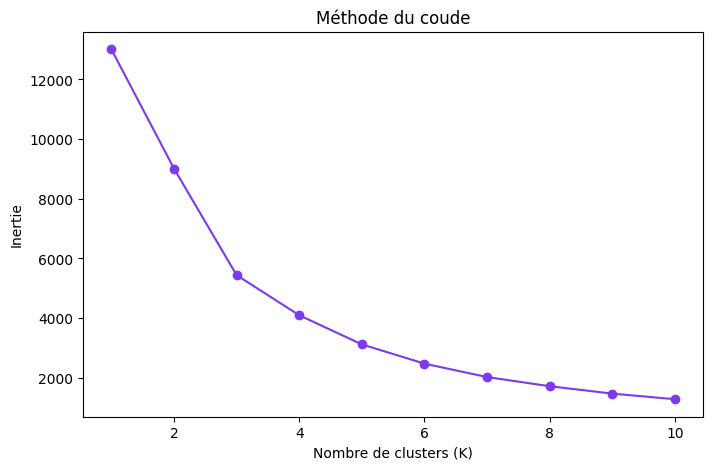

In [14]:
# Méthode du coude
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='#7c3aed')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.show()

**Lecture de la méthode du coude**

La courbe chute fortement jusqu'à K=3, puis s'aplatit progressivement. Le coude se situe autour de **K=3 ou K=4**. Pour trancher, on s'appuie sur le score de silhouette.

In [15]:
# Score de silhouette pour confirmer le nombre de clusters
silhouette_scores = {}
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    silhouette_scores[k] = silhouette_score(rfm_scaled, labels)

silhouette_scores

{2: 0.8958249711727472,
 3: 0.5942233320872992,
 4: 0.6162275299061803,
 5: 0.6165002474679847,
 6: 0.5982885618366588}

**Question : combien de clusters retenir ?**

Le score de silhouette est maximal pour **K=2 (0,90)**, mais ce découpage se contente d'isoler une poignée de clients extrêmes : il est statistiquement net mais **sans valeur métier**. Entre K=3, 4 et 5, les scores sont proches (0,59 à 0,62). On retient **K=4**, qui offre le meilleur compromis entre qualité statistique et exploitabilité marketing, tout en restant cohérent avec la méthode du coude. Cela correspond aux 4 profils attendus : réguliers, à risque, VIP et premium.

In [16]:
# Modèle final K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [17]:
# Profil moyen de chaque cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
})
cluster_profile.columns = ['Recency_moy', 'Frequency_moy', 'Monetary_moy', 'Nb_clients']
cluster_profile

,Recency_moy,Frequency_moy,Monetary_moy,Nb_clients
Cluster,,,,
0,43.702685,3.682711,1353.625312,3054
1,248.075914,1.552015,478.848773,1067
2,7.384615,82.538462,127187.959231,13
3,15.500000,22.333333,12690.500392,204


**Question : combien de groupes observe-t-on et que représentent-ils ?**

On observe **4 segments** bien distincts :
- **Cluster 0 — Réguliers** (~3 054 clients) : récence moyenne, faible fréquence, montant modéré.
- **Cluster 1 — À risque** (~1 067 clients) : récence très élevée (~248 jours), achats rares, faible montant.
- **Cluster 2 — VIP** (~13 clients) : achats très fréquents et très récents, montants énormes (~127 000 €).
- **Cluster 3 — Premium** (~204 clients) : récents, fidèles, bon panier (~12 690 €).

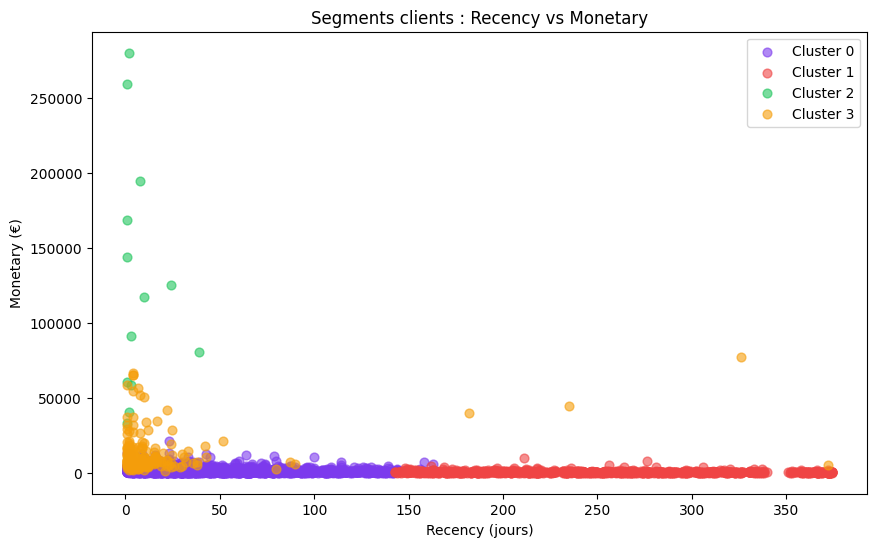

In [18]:
# Visualisation des clusters : Recency vs Monetary
plt.figure(figsize=(10, 6))

colors = ['#7c3aed', '#ef4444', '#22c55e', '#f59e0b']

for cluster in range(4):
    data = rfm[rfm['Cluster'] == cluster]
    plt.scatter(
        data['Recency'],
        data['Monetary'],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        s=40,
        alpha=0.6
    )

plt.xlabel('Recency (jours)')
plt.ylabel('Monetary (€)')
plt.title('Segments clients : Recency vs Monetary')
plt.legend()
plt.show()

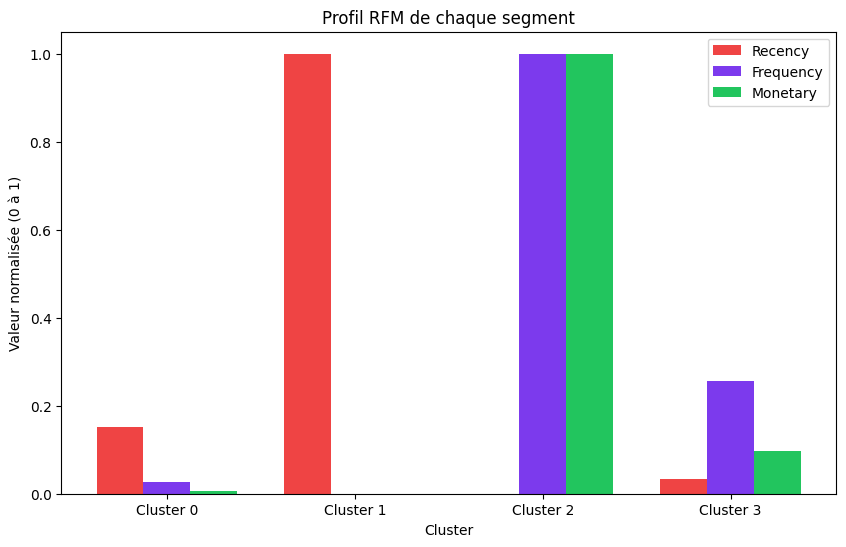

In [19]:
# Visualisation des profils RFM par cluster
import numpy as np

# Moyennes normalisées pour comparer R, F, M sur la même échelle
profile_norm = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
profile_scaled = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

# Graphique en barres groupées
x = np.arange(4)  # 4 clusters
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, profile_scaled['Recency'], width, label='Recency', color='#ef4444')
plt.bar(x, profile_scaled['Frequency'], width, label='Frequency', color='#7c3aed')
plt.bar(x + width, profile_scaled['Monetary'], width, label='Monetary', color='#22c55e')

plt.xlabel('Cluster')
plt.ylabel('Valeur normalisée (0 à 1)')
plt.title('Profil RFM de chaque segment')
plt.xticks(x, ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
plt.legend()
plt.show()

## Partie 5 - Interprétation métier

Chaque segment correspond à un type de client appelant une stratégie distincte :

- **Clients réguliers** : le socle de la clientèle. À fidéliser et inciter à acheter plus souvent.
- **Clients à risque** : en train de se désengager (pas d'achat depuis ~8 mois). À réactiver avec des offres ciblées.
- **Clients VIP** : très peu nombreux mais poids économique majeur, probablement des revendeurs. À choyer en priorité.
- **Clients premium** : meilleurs clients particuliers, récents et fidèles. À récompenser pour prévenir tout départ.

## Partie 6 - Sauvegarde pour le déploiement Streamlit

On sauvegarde le modèle K-Means, le scaler et le tableau RFM pour les réutiliser dans l'application.

In [20]:
import os

# Créer le dossier model s'il n'existe pas
os.makedirs("model", exist_ok=True)

# Sauvegarder le modèle K-Means et le scaler
joblib.dump(kmeans, "model/kmeans_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

# Sauvegarder le RFM avec les clusters pour le dashboard
rfm.to_csv("rfm_data.csv")


## Partie 7 - Amélioration : DBSCAN

DBSCAN ne nécessite pas de fixer le nombre de clusters et détecte automatiquement les clients atypiques (étiquette -1).

In [21]:
# PARTIE 7 : Amélioration - DBSCAN
from sklearn.cluster import DBSCAN

# DBSCAN sur les mêmes données normalisées
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(rfm_scaled)

# Compter les clusters trouvés (et les anomalies)
rfm['Cluster_DBSCAN'].value_counts()

Cluster_DBSCAN
 0    4284
-1      54
Name: count, dtype: int64

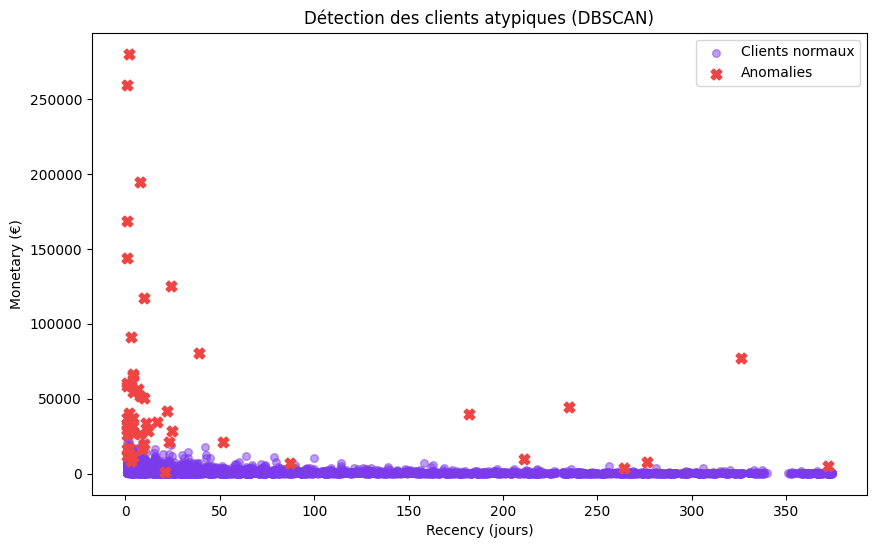

In [22]:
# Visualiser les anomalies détectées par DBSCAN
plt.figure(figsize=(10, 6))

# Clients normaux
normaux = rfm[rfm['Cluster_DBSCAN'] == 0]
plt.scatter(normaux['Recency'], normaux['Monetary'],
            c='#7c3aed', label='Clients normaux', s=30, alpha=0.5)

# Anomalies
anomalies = rfm[rfm['Cluster_DBSCAN'] == -1]
plt.scatter(anomalies['Recency'], anomalies['Monetary'],
            c='#ef4444', label='Anomalies', s=60, marker='X')

plt.xlabel('Recency (jours)')
plt.ylabel('Monetary (€)')
plt.title('Détection des clients atypiques (DBSCAN)')
plt.legend()
plt.show()

**Question : pourquoi ces points sont-ils considérés comme des anomalies ?**

DBSCAN repère **54 clients atypiques** (étiquette -1) : ce sont les très gros dépensiers, isolés du reste car aucun voisin proche ne partage leur profil dans l'espace RFM. Là où K-Means était obligé de les ranger dans un cluster, DBSCAN les identifie comme **exceptionnels**.

**Conclusion :** DBSCAN est complémentaire de K-Means. Il excelle dans la **détection d'anomalies**, mais ne fournit pas ici une segmentation marketing équilibrée. K-Means reste le meilleur choix pour segmenter l'ensemble de la clientèle.